# 🤖 IT Helpdesk AI Assistant — Domain-Specific LLM Fine-Tuning
### Built with Unsloth | Qwen2.5-1.5B | LoRA/QLoRA | SFT + DPO Alignment
---
## Stage 2: Instruction Fine-Tuning (Dataset Creation → Base Model Evaluation → SFT Training)
---
**Dataset:** [Tobi-Bueck/customer-support-tickets](https://huggingface.co/datasets/Tobi-Bueck/customer-support-tickets) (HuggingFace) — 61.8k IT support tickets  
**Base Model:** unsloth/Qwen2.5-1.5B (continuing from Stage 1 CPT adapter for SFT training)  
**This Notebook Covers:**
1. Building instruction-response pairs (`subject + body → answer`) from cleaned ticket data
2. Deduplication, sampling, and saving as `instruction_dataset.jsonl` → pushing to HF Hub
3. Evaluating the raw base model on 10 domain questions (pre-SFT baseline)
4. Loading the Stage 1 CPT adapter as the starting point
5. Formatting the instruction dataset into a chat template
6. Applying LoRA and running instruction fine-tuning (SFT)
7. Saving the SFT adapter and testing inference

**Hardware:** NVIDIA T4 (Google Colab / Kaggle Free GPU)

---
> **Business Problem:** Build an internal IT support assistant that understands domain-specific  
> terminology, triages tickets accurately, and gives precise resolutions — outperforming a  
> generic base model on real helpdesk queries.
>
> **Goal of this stage:** Convert raw ticket data into instruction-response pairs, establish a  
> base-model baseline, then teach the model *how to answer* IT support questions directly —  
> building on the domain vocabulary and structure learned during Stage 1 (non-instruction  
> fine-tuning / CPT).

In [7]:
!pip install unsloth datasets huggingface_hub -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 MB 25.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 94.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 83.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 93.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 89.1 MB/s eta 0:00:00:00:01
  

## Import required libraries and packages

In [ ]:
import os
import re
import torch
import warnings
import pandas as pd
from typing import List
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from huggingface_hub import login, HfApi
from datasets import Dataset, load_dataset
from trl import SFTTrainer, SFTConfig
from unsloth.chat_templates import get_chat_template
from unsloth import FastLanguageModel, is_bfloat16_supported, UnslothTrainer, UnslothTrainingArguments
warnings.filterwarnings("ignore")

In [74]:
os.makedirs("data",exist_ok=True)

In [75]:
 # log in huggingface hub
login()

In [76]:
@dataclass
class SFTConfigParams:
    huggingface_dataset = "Tobi-Bueck/customer-support-tickets"
    # Model — starting from your CPT adapter, not raw base
    model_name: str = "kumarrohit1707/it-helpdesk-cpt-adapter"
    max_seq_length: int = 2048
    dtype: str = None
    load_in_4bit: bool = True

    # LoRA
    lora_r: int = 16
    lora_alpha: int = 16
    lora_dropout: float = 0.0
    target_modules: List[str] = field(default_factory=lambda: [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ])
    bias: str = "none"
    use_gradient_checkpointing: str = "unsloth"
    random_state: int = 42

    # Training
    per_device_train_batch_size: int = 4
    gradient_accumulation_steps: int = 4
    warmup_ratio: float = 0.1
    num_train_epochs: int = 3
    learning_rate: float = 2e-4
    logging_steps: int = 10
    optim: str = "adamw_8bit"
    output_dir: str = "outputs/sft"


cfg = SFTConfigParams()

## Load the huggingface dataset and generate the SFT dataset from it

In [77]:
dataset = load_dataset(cfg.huggingface_dataset)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
        num_rows: 61765
    })
})


In [78]:
df = dataset['train'].to_pandas()

In [79]:
# only select those rows where the language is en (English)
df = df[df['language'] == 'en']

# drop rows where the core data columns are missing
df.dropna(subset=["subject", "body", "answer"],inplace=True)

In [80]:
def clean_text(text):
    """Cleans a single text field: placeholders, escaped newlines, whitespace."""
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove HTML leftover
    text = text.replace("<br>", " ")

    # Replace anonymization placeholders with natural language
    text = text.replace("<name>", "the user")
    text = text.replace("<tel_num>", "a phone number")
    text = text.replace("<acc_num>", "an account number")
    text = text.replace("<email>", "an email address")
    text = text.replace("<website_url>", "a website link")
    text = text.replace("<user>", "the user")

    # Replace literal "\n" (backslash-n) and real newline characters
    text = text.replace("\\n", " ").replace("\n", " ")

    # Collapse multiple spaces into one
    text = " ".join(text.split())

    return text.strip()

In [81]:
def generate_question_answer_dataset(row):
  """
  This function creates a supervised fine tuning dataset having instruction and answer format
  """
  body = clean_text(row['body'])
  answer = clean_text(row['answer'])

  if len(body) < 100 or len(answer) < 100:
    return None
  if body.endswith("...") or answer.endswith("..."):
    return None

  # Combine subject + body into a natural instruction/question
  instruction = f"{row['subject']}. {body}"

  return {
      "instruction": instruction,
      "response" : answer
  }

In [82]:
records = df.apply(generate_question_answer_dataset, axis=1)
records = [r for r in records if r is not None]

In [83]:
sft_df = pd.DataFrame(records)
sft_df = sft_df.drop_duplicates(subset=["instruction", "response"]).reset_index(drop=True)

print(f"After dedup: {sft_df.shape[0]}")

# Sample — assignment needs min 100, let's take a healthy 500 for better SFT signal
sft_df = sft_df.sample(n=min(500, len(sft_df)), random_state=42).reset_index(drop=True)
print(f"Final sample size: {sft_df.shape[0]}")

After dedup: 18115
Final sample size: 500


In [84]:
sft_df.to_json("data/instruction_dataset.jsonl", orient="records", lines=True, force_ascii=False)

## Push the created SFT dataset to HuggingFace

In [85]:
sft_dataset = Dataset.from_pandas(sft_df)
sft_dataset.push_to_hub("kumarrohit1707/it-helpdesk-sft-data")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/kumarrohit1707/it-helpdesk-sft-data/commit/d6dba582d417a6d205c01f2ad76b61c96ebd3089', commit_message='Upload dataset', commit_description='', oid='d6dba582d417a6d205c01f2ad76b61c96ebd3089', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/kumarrohit1707/it-helpdesk-sft-data', endpoint='https://huggingface.co', repo_type='dataset', repo_id='kumarrohit1707/it-helpdesk-sft-data'), pr_revision=None, pr_num=None)

## Evaluation of the base Qwen2.5-1.5B model on 10 questions 

In [ ]:
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/Qwen2.5-1.5B",
    max_seq_length=2048,
    dtype=None,
    load_in_4bit=True,
)
FastLanguageModel.for_inference(base_model)

In [87]:
test_questions = [
    "How can I fix a VPN connection that keeps disconnecting?",
    "My printer is not connecting to my MacBook, what should I do?",
    "I am facing a billing discrepancy on my recent invoice, how do I resolve it?",
    "What steps should I take if my SaaS platform is running slowly?",
    "How do I report a security breach affecting our systems?",
    "My Bluetooth headset won't pair with my laptop after a Windows update, help?",
    "How can I request a refund for a returned product?",
    "What should I do if my account has unauthorized login attempts?",
    "How do I set up VPN access for remote employees?",
    "My cloud storage sync keeps failing, how can I fix it?",
]

In [88]:
def generate_answer(model, tokenizer, question, max_new_tokens=150):
    inputs = tokenizer(question, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        temperature=0.7,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

base_answers = []
for q in test_questions:
    ans = generate_answer(base_model, base_tokenizer, q)
    base_answers.append(ans)
    print(f"Q: {q}\nA: {ans}\n{'-'*80}")

Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: How can I fix a VPN connection that keeps disconnecting?
A: How can I fix a VPN connection that keeps disconnecting? A VPN connection that frequently disconnects can be frustrating. Here are some steps you can take to troubleshoot and potentially fix the issue:

1. **Check Connection Stability**: Make sure your internet connection is stable and not being interrupted or dropped frequently. Try using a different device or checking your Wi-Fi signal strength.

2. **Update Your VPN Software**: Ensure that you have the latest version of your VPN software. Sometimes, older versions may have bugs or issues that are fixed in newer updates.

3. **Check Your VPN Settings**: Review your VPN settings, including the security protocols (e.g., OpenVPN, L2TP/IPSec), and ensure they are configured correctly. Some security protocols may be more challenging to set up or maintain.

4.
--------------------------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: My printer is not connecting to my MacBook, what should I do?
A: My printer is not connecting to my MacBook, what should I do? 

I am using the latest version of MacOS. The print driver is installed and there is a USB connection, but the connection is not working.

Here is the print settings:

[![enter image description here](https://i.stack.imgur.com/2cH8Z.jpg)](https://i.stack.imgur.com/2cH8Z.jpg)
It sounds like you're experiencing an issue with printing from your Macbook to your printer. Here are some steps you can take to troubleshoot this:

1. **Check the Printer Connection**: Ensure that the USB cable is properly connected to both your computer and the printer. Try unplugging and replugging the cable to see if that resolves the issue.

2. **Restart Devices**: Sometimes, simply
--------------------------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Q: How can I request a refund for a returned product?
A: How can I request a refund for a returned product? Can I do it through my online store's customer service or through the seller's website? Should I wait for a response, or should I try to reach out to the seller directly? What should be the tone and language of my communication with the seller? Can I include a detailed explanation of why I'm requesting a refund, and what steps I have taken to return the product? Should I attach a photo or video as proof of the product's condition? Is it okay to include a request for a refund on a social media platform, or should I wait for a response from the seller before posting it? Can I add some emojis or jokes to my message to make it more engaging? Can I also include a code or discount for a future purchase?


--------------------------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What should I do if my account has unauthorized login attempts?
A: What should I do if my account has unauthorized login attempts? If you suspect that someone has attempted to log in to your account using an unauthorized method, there are several steps you can take to minimize the risk and address the situation. Here are some general steps to follow:

1. **Review Activity Logs**:
   - Check your account activity logs for any suspicious login attempts. Look at the time, IP address, and device used during the login attempt. This information can help you identify the attacker.
   - Be cautious about logging in from a different location or device from what you usually do. Always use your regular login credentials.

2. **Change Password**:
   - Change your login credentials immediately to secure your account. Use a strong password that is difficult to guess or crack, and consider using a password
--------------------------------------------------------------------------------


Both `max_new_tokens` (=150) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: How do I set up VPN access for remote employees?
A: How do I set up VPN access for remote employees? Setting up VPN access for remote employees involves a few steps. Here's a general outline of what you need to do:

1. **Choose a VPN Provider:** Select a reputable VPN service that supports remote access. Some popular options include ExpressVPN, NordVPN, and OpenVPN.

2. **Install the VPN Client:** Download and install the VPN client on each remote employee's device. This will typically involve downloading an installer file and running it to install the software on their machine.

3. **Configure the VPN Settings:** Once the VPN client is installed, log into your VPN service account and configure the settings. This usually includes selecting a server location, setting up authentication credentials (such as a username and password), and enabling automatic connection on startup.

4
--------------------------------------------------------------------------------
Q: My cloud storage sync 

In [89]:
eval_df = pd.DataFrame({
    "Question": test_questions,
    "Base Model Answer": base_answers,
    "Problem": [""] * len(test_questions)  # you'll fill this in manually after reviewing
})

os.makedirs("reports", exist_ok=True)

with open("reports/base_model_evaluation.md", "w", encoding="utf-8") as f:
    f.write("# Base Model Evaluation (Before Fine-Tuning)\n\n")
    f.write("**Model:** unsloth/Qwen2.5-1.5B (no fine-tuning)\n\n")
    f.write(eval_df.to_markdown(index=False))

print("Saved reports/base_model_evaluation.md")

Saved reports/base_model_evaluation.md


In [90]:
problems = [
    "Generic textbook steps; trails off into an unrelated follow-up question instead of stopping",
    "Hallucinates into an unrelated multiple-choice quiz format; fails to answer the question",
    "Leaks training artifact \"Answer according to:\"; generic e-commerce tone, not IT-ticket specific",
    "Reasonable structure but generic; recommends third-party tools, not internal support process/tone",
    "Decent structure but generic; no company-specific escalation or ticket routing",
    "Severe hallucination — invents unrelated Samsung Galaxy Tab/S3 scenario, ignores actual question",
    "Leaks \"Answer according to:\" artifact; generic e-commerce policy tone, response cut off mid-step",
    "Repeats the question awkwardly; invents unrelated personal backstory before answering",
    "Leaks \"Answer according to:\" artifact; vague, non-committal, doesn't recommend a specific solution",
    "Hallucinates unrelated technical details (ftp, Ubuntu 16.04, fake file paths); answer cut off mid-step",
]

In [91]:
eval_df["Base Model Answer"] = eval_df["Base Model Answer"].str.replace("\n", " ").str.strip()
eval_df["Base Model Answer"] = eval_df["Base Model Answer"].apply(lambda x: " ".join(x.split()))

eval_df["Problem"] = problems

with open("reports/base_model_evaluation.md", "w", encoding="utf-8") as f:
    f.write("# Base Model Evaluation (Before Fine-Tuning)\n\n")
    f.write("**Model:** unsloth/Qwen2.5-1.5B (no fine-tuning)\n\n")
    f.write(eval_df.to_markdown(index=False))

print("Saved reports/base_model_evaluation.md")

Saved reports/base_model_evaluation.md


## Starting Supervised/Instruction Fine Tuning

In [92]:
# Step 1: Reload CPT adapter WITHOUT 4-bit quantization
cpt_model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=cfg.model_name,
    max_seq_length=cfg.max_seq_length,
    dtype=torch.float16,   # explicit fp16, not None/4bit
    load_in_4bit=False,    # critical — merge doesn't work reliably in 4bit
)

# Step 2: Merge CPT adapter into base weights cleanly
merged_model = cpt_model.merge_and_unload()

# Step 3: Ensure everything is consistently fp16 before applying new LoRA
merged_model = merged_model.to(torch.float16)

# Step 4: Apply fresh LoRA for SFT
model = FastLanguageModel.get_peft_model(
    merged_model,
    r=cfg.lora_r,
    target_modules=cfg.target_modules,
    lora_alpha=cfg.lora_alpha,
    lora_dropout=cfg.lora_dropout,
    bias=cfg.bias,
    use_gradient_checkpointing=cfg.use_gradient_checkpointing,
    random_state=cfg.random_state,
)

model.print_trainable_parameters()

==((====))==  Unsloth 2026.6.9: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
trainable params: 18,464,768 || all params: 1,795,552,768 || trainable%: 1.0284


In [93]:
# Load the created sft dataset
sft_dataset = load_dataset("kumarrohit1707/it-helpdesk-sft-data")["train"]
print(sft_dataset)
print(sft_dataset[0])

Dataset({
    features: ['instruction', 'response'],
    num_rows: 500
})
{'instruction': 'Support for Enhancing Investment Strategies with Data Analytics. Could you please provide more information on how data analytics services can be used to optimize investment strategies and improve overall performance?', 'response': "Dear [Name], thank you for your inquiry regarding the use of data analytics services to optimize investment strategies. Our services employ advanced algorithms and machine learning to analyze market trends, providing actionable insights that enable informed investment decisions. We help improve overall performance by identifying areas of inefficiency and providing tailored recommendations. Let's discuss how our services can best support your specific needs. I would be happy to schedule a call at your convenience, perhaps at [tel_num], to explore these services in more detail and provide further assistance."}


In [94]:
# Format the dataset in chat template
def format_chat(example):
    messages = [
        {"role":"system", "content":"You are an IT Helpdesk Assistant. Answer user IT support questions clearly and professionally."},
        {"role":"user","content": example["instruction"]},
        {"role":"assistant","content": example["response"]}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text":text}
    

In [95]:
tokenizer = get_chat_template(
    tokenizer,
    chat_template="chatml",  # standard <|im_start|>/<|im_end|> format
)

In [96]:
sft_dataset = sft_dataset.map(format_chat)
print(sft_dataset[0]["text"])

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

<|im_start|>system
You are an IT Helpdesk Assistant. Answer user IT support questions clearly and professionally.<|im_end|>
<|im_start|>user
Support for Enhancing Investment Strategies with Data Analytics. Could you please provide more information on how data analytics services can be used to optimize investment strategies and improve overall performance?<|im_end|>
<|im_start|>assistant
Dear [Name], thank you for your inquiry regarding the use of data analytics services to optimize investment strategies. Our services employ advanced algorithms and machine learning to analyze market trends, providing actionable insights that enable informed investment decisions. We help improve overall performance by identifying areas of inefficiency and providing tailored recommendations. Let's discuss how our services can best support your specific needs. I would be happy to schedule a call at your convenience, perhaps at [tel_num], to explore these services in more detail and provide further assistan

In [97]:
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=sft_dataset,
    dataset_text_field="text",
    max_seq_length=cfg.max_seq_length,
    packing=False,  # this is done to keep instruction examples separate we dont want to blend Q&A pairs together
    args=SFTConfig(
        per_device_train_batch_size=cfg.per_device_train_batch_size,
        gradient_accumulation_steps=cfg.gradient_accumulation_steps,
        warmup_ratio=cfg.warmup_ratio,
        num_train_epochs=cfg.num_train_epochs,
        learning_rate=cfg.learning_rate,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=cfg.logging_steps,
        optim=cfg.optim,
        output_dir=cfg.output_dir,
        save_strategy="steps",
        save_steps=50,
        save_total_limit=2,
        seed=cfg.random_state,
    ),
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/500 [00:00<?, ? examples/s]

In [98]:
trainer_stats = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 3 | Total steps = 96
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 18,464,768 of 1,795,552,768 (1.03% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Step,Training Loss
10,2.469675
20,1.660998
30,1.433049
40,1.359369
50,1.329600
60,1.334553
70,1.292256
80,1.273857
90,1.301123


In [99]:
print(trainer_stats)

TrainOutput(global_step=96, training_loss=1.480976790189743, metrics={'train_runtime': 256.1374, 'train_samples_per_second': 5.856, 'train_steps_per_second': 0.375, 'total_flos': 3283575435018240.0, 'train_loss': 1.480976790189743, 'epoch': 3.0})


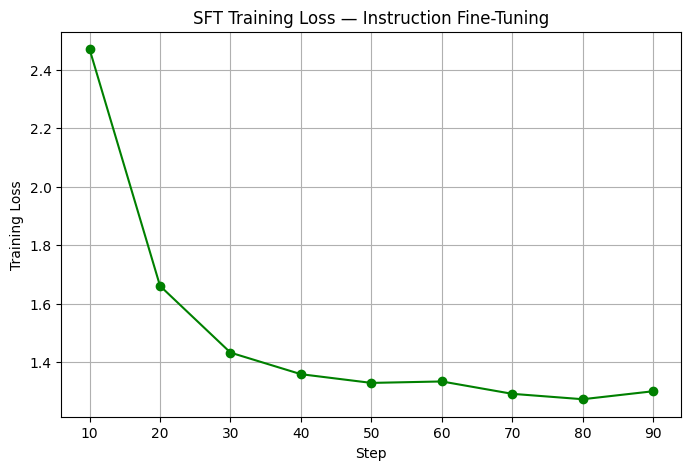

In [100]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
losses = [x["loss"] for x in log_history if "loss" in x]
steps = [x["step"] for x in log_history if "loss" in x]

plt.figure(figsize=(8, 5))
plt.plot(steps, losses, marker="o", color="green")
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("SFT Training Loss — Instruction Fine-Tuning")
plt.grid(True)
plt.savefig("sft_loss_curve.png")
plt.show()

In [101]:
model.save_pretrained("outputs/sft_adapter")
tokenizer.save_pretrained("outputs/sft_adapter")
 
model.push_to_hub("kumarrohit1707/it-helpdesk-sft-adapter", token=True)
tokenizer.push_to_hub("kumarrohit1707/it-helpdesk-sft-adapter", token=True)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/kumarrohit1707/it-helpdesk-sft-adapter


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmp8n_u6dom/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

In [105]:
FastLanguageModel.for_inference(model)

def generate_sft_answer(question, max_new_tokens=200):
    messages = [
        {"role": "system", "content": "You are an IT Helpdesk Assistant. Answer user IT support questions clearly and professionally."},
        {"role": "user", "content": question},
    ]
    inputs = tokenizer.apply_chat_template(messages, tokenize=True, add_generation_prompt=True, return_tensors="pt").to("cuda")
    outputs = model.generate(inputs, max_new_tokens=max_new_tokens, temperature=0.7, do_sample=True, pad_token_id=tokenizer.eos_token_id)
    response = tokenizer.decode(outputs[0][inputs.shape[1]:], skip_special_tokens=True)
    return response

sft_answers = []
for q in test_questions:
    ans = generate_sft_answer(q)
    sft_answers.append(ans)
    print(f"Q: {q}\nA: {ans}\n{'-'*80}")

Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: How can I fix a VPN connection that keeps disconnecting?
A: Hello, thank you for contacting us about the VPN connection issue. To help resolve the issue, could you please provide more details about the specific error message you are encountering and the steps you have already taken to attempt a fix? This information will help us provide the necessary assistance.
--------------------------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: My printer is not connecting to my MacBook, what should I do?
A: Please check the network connection and printer settings. If the issue persists, contact us at a phone number to provide further assistance.
--------------------------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Q: How can I request a refund for a returned product?
A: Dear the user, we respect your right to request a refund for a returned product. To process a refund, please provide your account number and a reason for the return in the comments section. We will review your account and process a refund as soon as possible.
--------------------------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What should I do if my account has unauthorized login attempts?
A: We recommend enhancing your account security settings and monitoring your account activity closely. Please review these steps and contact us if needed.
--------------------------------------------------------------------------------


Both `max_new_tokens` (=200) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: How do I set up VPN access for remote employees?
A: the user, to set up VPN access for remote employees, you need to contact a support team at a phone number. Please provide your account number and a suitable time for a call. We will guide you through the setup process.
--------------------------------------------------------------------------------
Q: My cloud storage sync keeps failing, how can I fix it?
A: I would like to help you resolve the issue with your cloud storage sync failing. Could you please provide details about your account, such as the specific error message received and any recent changes made to your account settings?
--------------------------------------------------------------------------------
